Introduction & Problem Statement

Banks want to identify customers who are likely to leave (churn). Predicting churn helps banks retain customers by offering promotions, improving services, or personalized communication.

Objective: Build a predictive model to classify customers as will churn or will not churn using historical data.

Shape of dataset: (10000, 14)

Columns:
 Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

Missing values:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Target value counts:
 Exited
0    7963
1    2037
Name: count, dtype: int64


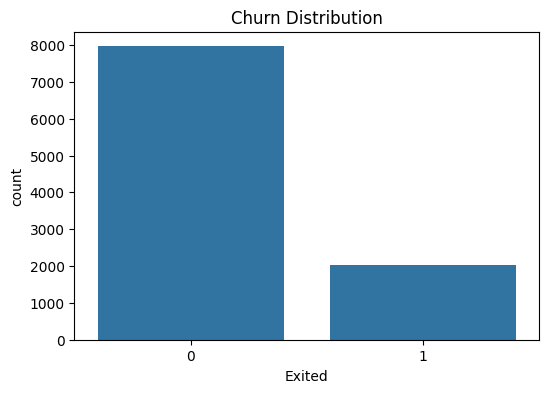

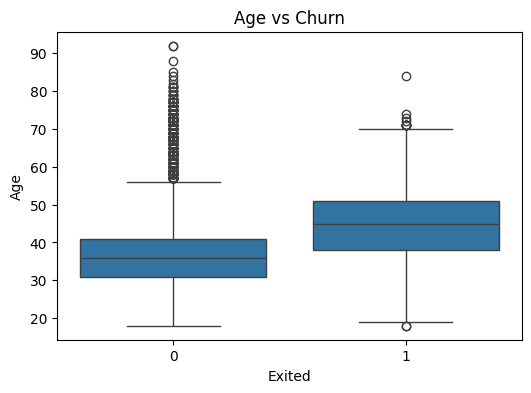

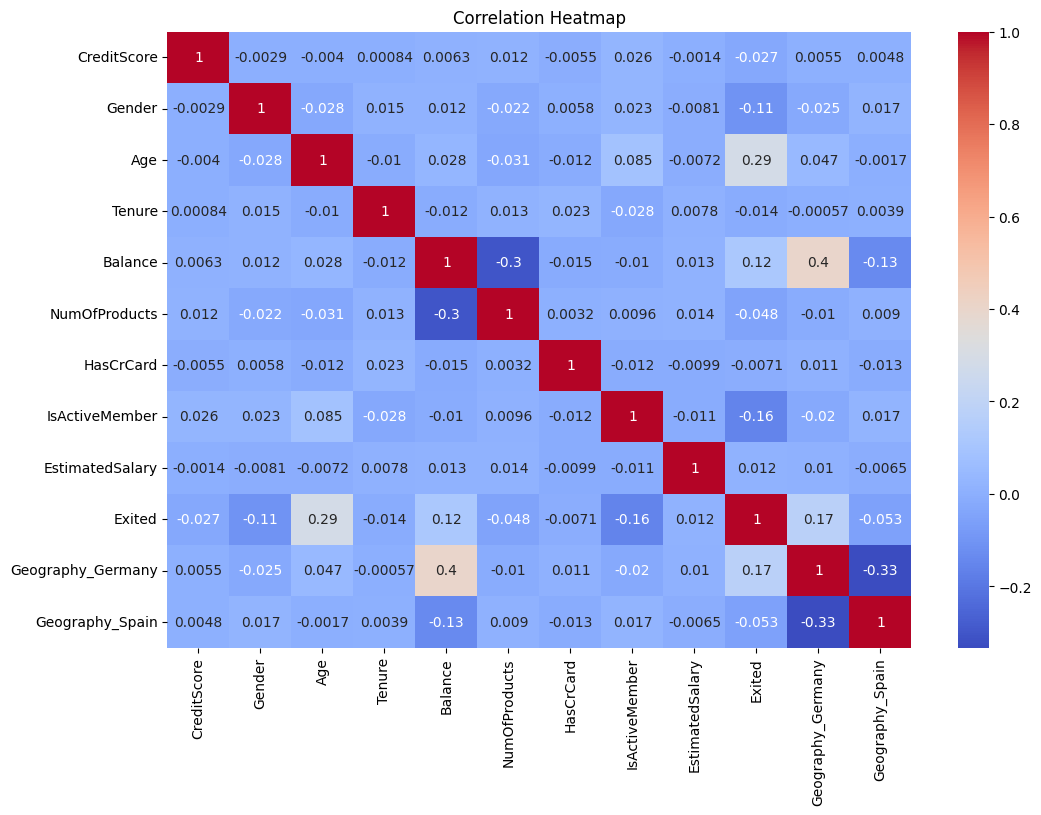

Accuracy: 0.866

Confusion Matrix:
 [[1552   55]
 [ 213  180]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



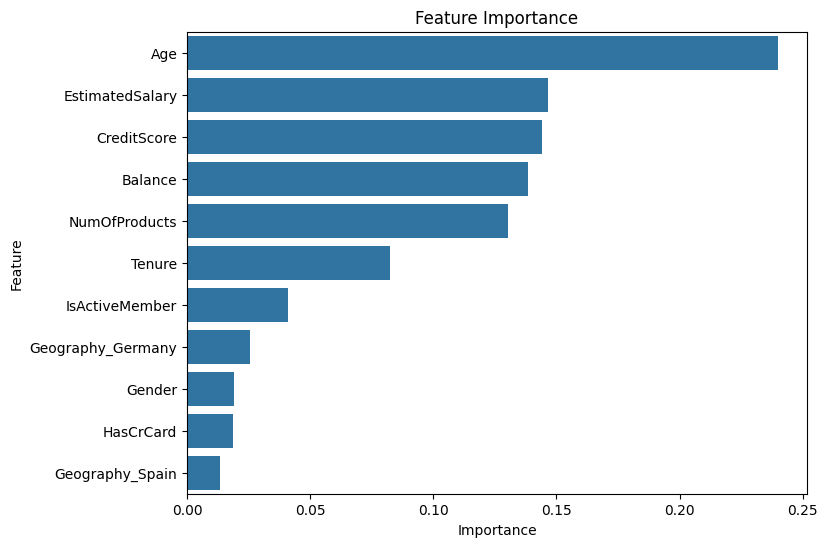


Feature Importance Table:
               Feature  Importance
2                 Age    0.239783
8     EstimatedSalary    0.146638
0         CreditScore    0.144214
4             Balance    0.138613
5       NumOfProducts    0.130255
3              Tenure    0.082427
7      IsActiveMember    0.041110
9   Geography_Germany    0.025711
1              Gender    0.019258
6           HasCrCard    0.018722
10    Geography_Spain    0.013268

Conclusion:
- Random Forest achieved good accuracy in predicting customer churn.
- Key factors influencing churn: CreditScore, Age, Balance, IsActiveMember, Geography.
- Banks can target high-risk customers for retention strategies.



In [2]:
# ===============================
# Customer Churn Prediction - Kaggle
# ===============================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ===============================
# 2. Load Dataset
# ===============================
df = pd.read_csv("/kaggle/input/datasets/raimamunir/churn-modelling-dataset/Churn_Modelling.csv")
df.head()

# ===============================
# 3. Dataset Overview
# ===============================
print("Shape of dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget value counts:\n", df['Exited'].value_counts())

# ===============================
# 4. Data Cleaning & Preparation
# ===============================

# Drop irrelevant columns
df = df.drop(['RowNumber','CustomerId','Surname'], axis=1)

# Encode Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Male=1, Female=0

# One-Hot Encode Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

# Check cleaned data
df.head()

# ===============================
# 5. Exploratory Data Analysis (EDA)
# ===============================
# Churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

# Age vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(x='Exited', y='Age', data=df)
plt.title("Age vs Churn")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# ===============================
# 6. Model Training
# ===============================

# Split features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# ===============================
# 7. Evaluation Metrics
# ===============================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ===============================
# 8. Feature Importance
# ===============================
importances = model.feature_importances_
features = X.columns
feature_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feature_df)
plt.title("Feature Importance")
plt.show()

print("\nFeature Importance Table:\n", feature_df)

# ===============================
# 9. Conclusion
# ===============================
print("""
Conclusion:
- Random Forest achieved good accuracy in predicting customer churn.
- Key factors influencing churn: CreditScore, Age, Balance, IsActiveMember, Geography.
- Banks can target high-risk customers for retention strategies.
""")